In [9]:
/** @jsxImportSource @nic/openscad-jsx */

import { ComponentChildren, renderToString, type JSX } from "@nic/openscad-jsx";
import { renderToSTL, renderToImage, configureJupyter } from "@nic/openscad-jsx/deno";

configureJupyter({
  viewportHeight: 300,
  backgroundColor: 0xffffff,
  defaultColor: 0xaaaa00,
  gridSize: 200,
});

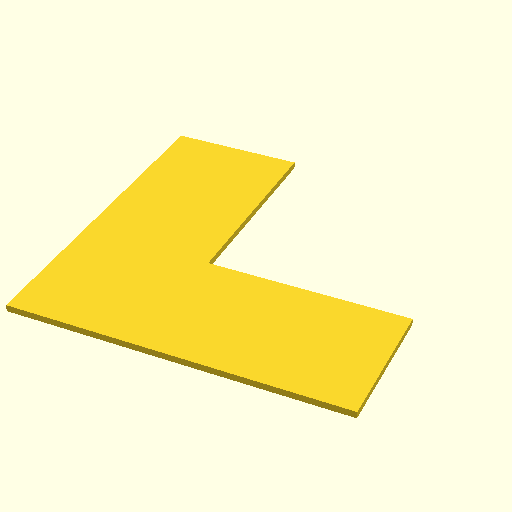

In [10]:
/** @jsxImportSource @nic/openscad-jsx */

import { IntrinsicCADElement } from "@nic/openscad-jsx";

class Polygon extends IntrinsicCADElement<{ points: [number, number][] }> {
  renderToString(): string {
    const pointsStr = this.props.points
      .map(([x, y]) => `[${x}, ${y}]`)
      .join(", ");
    return `polygon([${pointsStr}]);`;
  }
}

await renderToImage(
  <Polygon
    points={[
      [0, 0],
      [50, 0],
      [50, 20],
      [20, 20],
      [20, 50],
      [0, 50],
    ]}
  />,
);

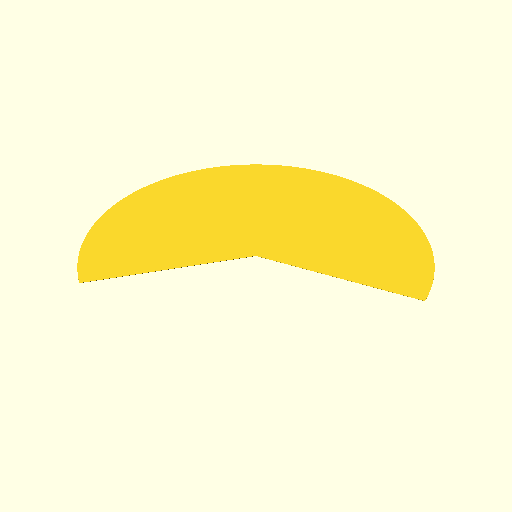

In [11]:
/** @jsxImportSource @nic/openscad-jsx */

function Angle({ angle, radius = 1000 }: { angle: number; radius?: number }) {
  if (angle < 0 || angle > 360) {
    throw new Error("Angle must be between 0 and 360 degrees");
  }

  const rad = (angle * Math.PI) / 180;

  const r = radius;
  const rTan = radius * Math.abs(Math.tan(rad));

  const points: [number, number][] = [[0, 0], [r, 0]];
  if (angle < 90) {
    points.push([r, rTan]);
  } else if (angle < 180) {
    points.push([r, r], [-r, rTan]);
  } else if (angle < 270) {
    points.push([r, r], [-r, r], [-r, -rTan]);
  } else if (angle < 360) {
    points.push([r, r], [-r, r], [-r, -r], [r, -rTan]);
  } else {
    return <circle r={radius} $fn={1000} />;
  }

  return (
    <intersection>
      <circle r={radius} $fn={1000} />
      <Polygon points={points} />
    </intersection>
  );
}

await renderToImage(<Angle angle={220} />);


In [12]:
let ccaRad: number;
let spaceBehind = 7;

//spaceBehind = 9 * (1 - Math.cos(ccaRad)) + 7 * (1 - Math.cos(ccaRad));
//spaceBehind = 16 - 16 * Math.cos(ccaRad);
// Math.cos(ccaRad) = 1 - spaceBehind / 16
ccaRad = Math.acos(1 - spaceBehind / 16);

const ccaDeg = (ccaRad * 180) / Math.PI;

ccaDeg;


55.771133672187425

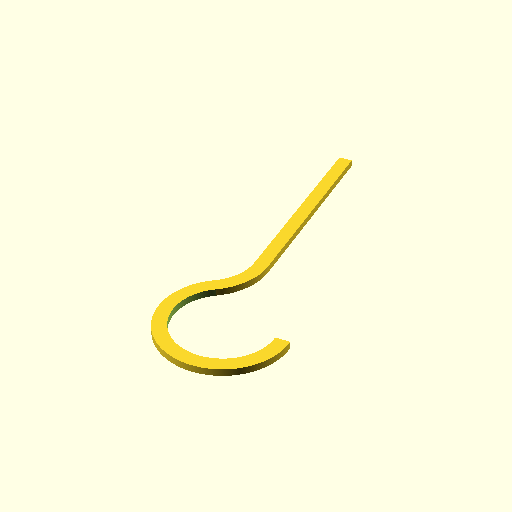

In [13]:
/** @jsxImportSource @nic/openscad-jsx */

const bar = (
  <translate x={7}>
    <rectangle sx={2} sy={30} />
  </translate>
);

const curvesConnectionAngle = ccaDeg;
const curvesConnectionAngleRad = ccaRad;

const curveSmall = (
  <rotate by={-curvesConnectionAngle}>
    <difference>
      <Angle radius={9} angle={curvesConnectionAngle} />
      <circle r={7} $fn={1000} />
    </difference>
  </rotate>
);

const curveSmallEndX = 8 * Math.cos(-curvesConnectionAngleRad);
const curveSmallEndY = 8 * Math.sin(-curvesConnectionAngleRad);

const curveLarge = (
  <translate x={0} y={0}>
    <rotate by={-(180 + curvesConnectionAngle)}>
      <difference>
        <Angle radius={9} angle={180 + curvesConnectionAngle} />
        <circle r={7} $fn={1000} />
      </difference>
    </rotate>
  </translate>
);

const curveLargeEndX = 8 * Math.cos(Math.PI - curvesConnectionAngleRad);
const curveLargeEndY = 8 * Math.sin(Math.PI - curvesConnectionAngleRad);

const hook2d = (
  <>
    {bar}
    {curveSmall}
    <translate
      x={curveSmallEndX - curveLargeEndX}
      y={curveSmallEndY - curveLargeEndY}
    >
      {curveLarge}
    </translate>
  </>
);

await renderToImage(hook2d);


In [ ]:
/** @jsxImportSource @nic/openscad-jsx */

const hook = (
  <difference>
    <extrusionLinear h={10}>{hook2d}</extrusionLinear>
    <translate z={5} y={25} x={7}>
      <rotate by={90} axis={[0, 1, 0]}>
        <>
          <cylinder r={1.85} h={12} $fn={6} />
          <cylinder topRadius={1.85} bottomRadius={2.3} h={0.5} $fn={6} />
        </>
      </rotate>
    </translate>
  </difference>
);

const stl = await renderToSTL(hook);

stl;


In [15]:
Deno.writeFileSync("hook2.stl", stl);